# Intro

Welcome to the interactive labeling notebook!

The notebook proceeds as follows:

1. **Import** libraries
2. Define **paths** to data
3. **Label** ROI images using a simple GUI
4. **Visualize** results
5. **Save** results


- If you need to restart a session, don't worry. Your results are continuously saved in the CSV file and you can just start from where you left off.
- We recommend labeling one session at a time so that the results can be saved with the data.

# Import libraries

Widen the notebook

In [1]:
# widen jupyter notebook window
from IPython.display import display, HTML
display(HTML("<style>.container {width:95% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

Import basic libraries

In [2]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

Import `roicat`

In [3]:
import roicat

# Find paths to data

##### Prepare list of paths to data

In this example we are using suite2p output files, but other data types can be used (CaImAn, etc.) \
See the notebook on ingesting diverse data: https://github.com/RichieHakim/ROICaT/blob/main/notebooks/jupyter/other/demo_data_importing.ipynb

Make a list containing the paths to all the input files.

In this example we are using suite2p, so the following are defined:
1. `paths_allStat`: a list to all the stat.npy files
2. `paths_allOps`: a list with ops.npy files that correspond 1-to-1 with the stat.npy files

In [7]:
# dir_data = r'/media/rich/bigSSD/other_lab_data/Allen_institute/David_Feng'
dir_data = r'/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R'

paths_stat = roicat.helpers.find_paths(
    dir_outer=dir_data,
    reMatch='stat\.npy',
    reMatch_in_path='exp',
    depth=8,
)

display(paths_stat)

paths_ops = [str(Path(p).parent / 'ops.npy') for p in paths_stat]

display(paths_ops)

['/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230426/scanimage_data/exp/jobNum_0/suite2p/plane0/stat.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230427/scanimage_data/exp/jobNum_0/suite2p/plane0/stat.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230428/scanimage_data/exp/jobNum_0/suite2p/plane0/stat.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230429/scanimage_data/exp/jobNum_0/suite2p/plane0/stat.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230430/scanimage_data/exp/jobNum_0/suite2p/plane0/stat.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230501/scanimage_data/exp/jobNum_0/suite2p/plane0/stat.npy']

['/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230426/scanimage_data/exp/jobNum_0/suite2p/plane0/ops.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230427/scanimage_data/exp/jobNum_0/suite2p/plane0/ops.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230428/scanimage_data/exp/jobNum_0/suite2p/plane0/ops.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230429/scanimage_data/exp/jobNum_0/suite2p/plane0/ops.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230430/scanimage_data/exp/jobNum_0/suite2p/plane0/ops.npy',
 '/Users/richardhakim/Documents/data/some_full_s2p_outputs_mouse_0322R/20230501/scanimage_data/exp/jobNum_0/suite2p/plane0/ops.npy']

In [8]:
data = roicat.data_importing.Data_suite2p(
    paths_statFiles=paths_stat,
    paths_opsFiles=paths_ops,
    new_or_old_suite2p='new',
    verbose=True,
)

assert data.check_completeness(verbose=False)['classification_inference'], f"Data object is missing attributes necessary for tracking."

Starting: Importing FOV images from ops files
Completed: Set FOV_height and FOV_width successfully.
Completed: Imported 6 FOV images.
Setting FOV_images...
Completed: Set FOV_images for 6 sessions successfully.
Importing spatial footprints from stat files.


  0%|          | 0/6 [00:00<?, ?it/s]

Imported 6 sessions of spatial footprints into sparse arrays.
Completed: Created session_bool.
Completed: Set spatialFootprints for 6 sessions successfully.
Completed: Created centroids.
Starting: Creating centered ROI images from spatial footprints...
Completed: Created ROI images.


# Label data

How to use this GUI:
- Each image will be shown one at a time. You can go to previous and next images by using the ***Left*** and ***Right*** arrow keys, and can close the GUI by pressing the ***Escape*** key.
- Label the image by pressing any key on your keyboard. This key will be used as the label. After each key press, the following occurs:
    1. The results will be saved as a CSV file at `path_csv` (will be a temporary file if not specified)
    2. The results will also be stored in the python object as `ImageLabeler_obj.labels_`.
    2. The GUI should progress to the next image.
    3. Finish labeling by closing out of the GUI window or pressing the user defined '`end_key`' (***Escape*** by default).
- The results are stored in a temporary CSV file with two columns: 'index' and 'label'. This file can be used to recover lost labeling session data. We will save more comprehensive results files at the end of the notebook.
    - **'index'**: The index within the data object. 0-indexed.
    - **'label'**: The key pressed for that image in the labeling GUI.
- To start at a different image index than 0, change the `start_index` argument.

In [12]:
images = np.concatenate(data.ROI_images, axis=0)

## Run the ImageLabeler class
with roicat.helpers.ImageLabeler(
    image_array=images, 
    start_index=0,  ## Change the starting image index here.
    path_csv=None,  ## If None, then a temporary path will be used.
    resize_factor=10.0,  
    verbose=True,
    key_end='Escape',  ## Closes GUI
    key_prev='Left',  ## Goes to previous image
    key_next='Right',  ## Goes to next image
) as labeler:  ## Running this object within a context manager allows it to crash gracefully
    labeler.run()
    
labels = {
    'labels_list': labeler.get_labels(kind='list'),
    'labels_dict': labeler.get_labels(kind='dict'),
    'labels_df': labeler.get_labels(kind='dataframe'),
}

print(f"Number of labeled ROIs: {len(labels['labels_list'])}")
print(f"path to csv file: {labeler.path_csv}")

Image 0: a
Image 1: s
Image 2: d
Image 3: f
Image 4: s
Image 5: a
Image 6: d
Image 7: f
Image 8: a
Image 9: s
Image 10: d
Image 11: f
Image 12: a
Image 13: s
Image 14: d
Image 15: f
Image 16: s
Image 17: d
Image 18: f
Image 19: s
Image 20: d
Image 21: f
Image 22: s
Image 23: a
Image 24: s
Image 25: d
Image 26: f
Image 27: s
Image 28: q
Number of labeled ROIs: 15432
path to csv file: /var/folders/rj/y1_9lfn16mg3r0j3qg45dxw40000gn/T/roicat_labels_20250915_180140.csv


In [13]:
labels = {
    'list': roicat.util.JSON_List(labeler.get_labels(kind='list')),
    'df': labeler.get_labels(kind='dataframe'),
}

# Visualize results

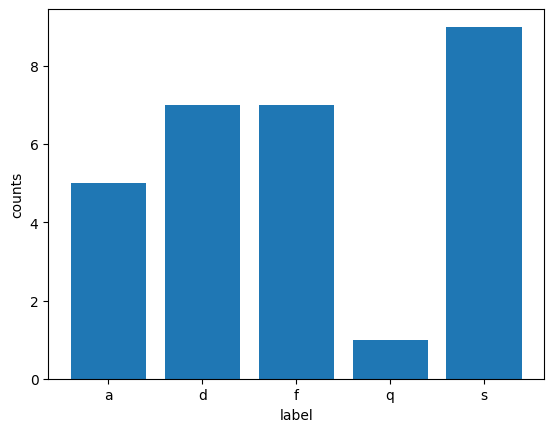

In [14]:
u, c = np.unique(labels['df']['label'], return_counts=True)

plt.figure()
plt.bar(u, c);
plt.xlabel('label');
plt.ylabel('counts');

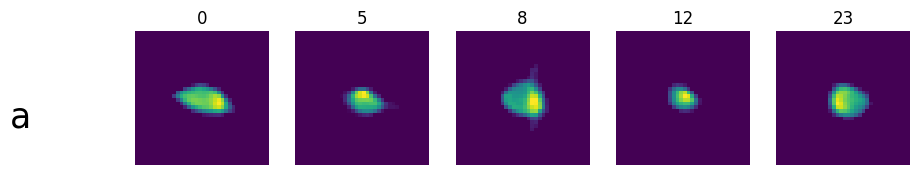

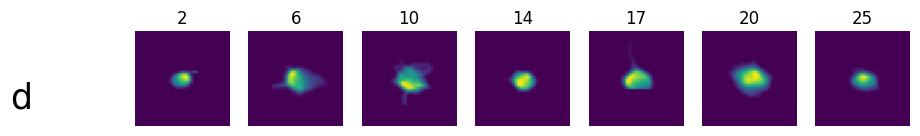

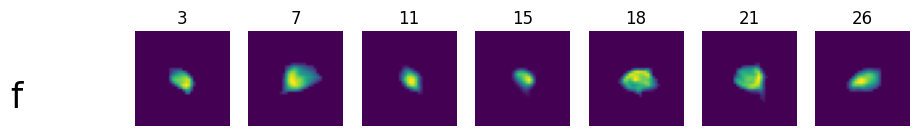

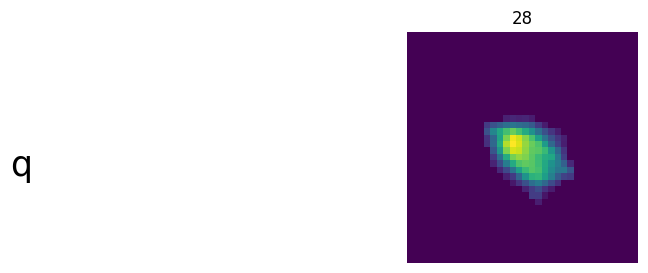

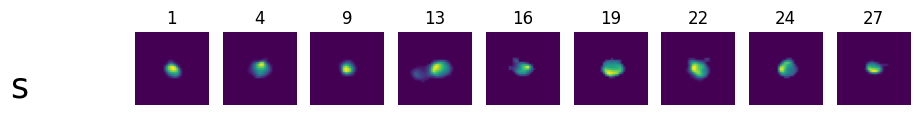

In [15]:
roicat.visualization.display_labeled_ROIs(
    images=images,
#     labels=labels['label'].astype(np.int64),
    labels=labels['df'],
    max_images_per_label=10,
    figsize=(10, 3),
    fontsize=25,
    shuffle=False,
)

# Save results

The results file can be opened using any of the following methods:
1. `roicat.helpers.pickle_load(path)`
2. `np.load(path)`
3. 
``` 
import pickle
with open(path_save, mode='rb') as f:
    test = pickle.load(f)
  ```

##### Make and save results

In [109]:
run_data = {
    "data": data.__dict__,
}
results = {
    "labels": labels,
    "images": images,
}

In [ ]:
## Define the directory to save the results to
dir_save = '/media/rich/bigSSD/data_tmp/test_data/'
name_save = 'mouse_1'

paths_save = {
    'labels':   str(Path(dir_save) / f'{name_save}.labeling.labels.csv'),
    'results':  str(Path(dir_save) / f'{name_save}.labeling.results.richfile'),
    'run_data': str(Path(dir_save) / f'{name_save}.labeling.run_data.richfile'),
}

## Save
labels['df'].to_csv(paths_save['labels'])
roicat.util.RichFile_ROICaT(path=paths_save['results']).save(results, overwrite=True)
roicat.util.RichFile_ROICaT(path=paths_save['run_data']).save(run_data, overwrite=True)

# Thank you
If you encountered any difficulties, please let us know at the issues page: https://github.com/RichieHakim/ROICaT/issues

---
# Extras

## Merge and convert GUI CSV files into a results file

##### 1. Make labels dictionary

In [99]:
import csv

# path_csv = r'/home/rich/Desktop/test.csv'  ## Path to the raw output .csv file from the GUI
path_csv = labeler.path_csv

with open(path_csv, 'r') as f:
    lines = np.array([line for line in csv.reader(f)], dtype=str)

labels_dict = {int(idx): label for idx, label in zip(lines[1:, 0], lines[1:, 1])}

##### 2. Make images array

In [ ]:
dir_data = r'/media/rich/bigSSD/downloads_tmp/tmp_data/mouse_0322R/statFiles/20230420/'


path_stat = str(Path(dir_data) / 'stat.npy')
path_ops = str(Path(dir_data) / 'ops.npy')

data = roicat.data_importing.Data_suite2p(
    paths_statFiles=[path_stat],
    paths_opsFiles=[path_ops],
    new_or_old_suite2p='new',
    verbose=True,
)

assert data.check_completeness(verbose=False)['classification_inference'], f"Data object is missing attributes necessary for tracking."

images = np.concatenate(data.ROI_images, axis=0)

##### 3. Make the results dictionary

In [103]:
import pandas as pd

labels_list = ['None'] * len(labels_dict)
for idx, label in labels_dict.items():
    labels_list[idx] = label

labels_df = pd.DataFrame(index=list(labels_dict.keys()), data=labels_list, columns=['label'])

labels = {
    'list': roicat.util.JSON_List(labels_list),
    'dict': roicat.util.JSON_Dict(labels_dict),
    'df': labels_df,
}

In [104]:
run_data = {
    "data": data.__dict__,
}
results = {
    "labels": labels,
    "images": images,
}

##### 4. Save the results dictionary

In [ ]:
## Define the directory to save the results to
dir_save = '/media/rich/bigSSD/data_tmp/test_data/'
name_save = 'mouse_1'

paths_save = {
    'labels':   str(Path(dir_save) / f'{name_save}.labeling.labels.json'),
    'results':  str(Path(dir_save) / f'{name_save}.labeling.results.richfile'),
    'run_data': str(Path(dir_save) / f'{name_save}.labeling.run_data.richfile'),
}

roicat.helpers.json_save(obj=roicat.util.JSON_List(labels['list']), filepath=paths_save['labels'])
roicat.util.RichFile_ROICaT(path=paths_save['results']).save(results, overwrite=True)
roicat.util.RichFile_ROICaT(path=paths_save['run_data']).save(run_data, overwrite=True)